In [1]:
import modules.data as d
import modules.model as m
import modules.train as t
import modules.utils as u

import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
from pathlib import Path
from typing import Literal, Callable


In [2]:
# dataset dir
datasets = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')

# get device
device, generator = u.Devices().auto_set_device()

# get data
brca = d.Data(
    # datasets
    tcga_project = 'TCGA-BRCA',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',

    # dirs
    tcga_dir = datasets / 'tcga',
    relation_filepath = datasets / 'other/relation_ohe.csv',
    
    # col, filter
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Metastatic']},
    max_subset=120,
)

*** Device() ***
device = cuda:2

**** Data() ****
log0_method      log1p            str
class_weights    (6,)             Tensor (cuda:2)
gene_counts      (4383, 567)      DataFrame
metadata         (567, 3)         DataFrame
relation         (75939, 19)      DataFrame
node_id_map      4383             dict
masks            305              list
X                (567, 4383, 1)   Tensor (cuda:2)
y                (567, 6)         Tensor (cuda:2)
y_labels         6                list
num_samples      567              int
num_nodes        4383             int
num_features     1                int
num_labels       6                int
num_masks        305              int



In [3]:
# # run experiment
# num_epochs = 40
# num_trials = 10

# brca_MLPc = t.Experiment(
#     data=brca,
#     generator=generator,

#     model_class=m.MLPClassifier,
#     model_kwargs={
#         'in_features':brca.num_nodes,
#         'out_features':brca.num_labels,
#         'flatten':True,
#     },

#     training_class=t.ClassifierTrainingModule,
#     training_kwargs={
#         'loss_fn':nn.CrossEntropyLoss(brca.class_weights),
#         'optimizer':torch.optim.Adam,
#         'num_epochs':num_epochs,
#         'report_metrics':['tot_loss', 'accuracy'],
#         'verbose':False
#     },

#     num_trials=num_trials,
#     comment='MLPc'
# )

# brca_GCNc = t.Experiment(
#     data=brca,
#     generator=generator,

#     model_class=m.GCNClassifier,
#     model_kwargs={
#         'in_features':brca.num_features,
#         'out_features':brca.num_labels,
#         'relation':brca.relation,
#         'num_nodes':brca.num_nodes,
#         'gcn_kwargs':{'end_fn':nn.LeakyReLU()}
#     },

#     training_class=t.ClassifierTrainingModule,
#     training_kwargs={
#         'loss_fn':nn.CrossEntropyLoss(brca.class_weights),
#         'optimizer':torch.optim.Adam,
#         'num_epochs':num_epochs,
#         'report_metrics':['tot_loss', 'accuracy'],
#         'verbose':False
#     },

#     num_trials=num_trials,
#     comment='GCNc'
# )

# display(brca_MLPc.summary)
# display(brca_GCNc.summary)


---

In [4]:
def check_self_loops(df):
    self_loops = df[df["idx1"] == df["idx2"]]
    has_self_loops = not self_loops.empty
    print(has_self_loops)
    return self_loops

check_self_loops(brca.relation)


True


,pathway_name,idx1,idx2,activation,binding/association,compound,dephosphorylation,dissociation,expression,glycosylation,indirect,indirect effect,inhibition,methylation,missing interaction,phosphorylation,repression,state change,ubiquitination
2631,path:hsa05169,332,332,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2632,path:hsa05169,332,332,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2633,path:hsa05169,333,333,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2634,path:hsa05169,333,333,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3644,path:hsa05205,465,465,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75818,path:hsa04922,900,900,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
75819,path:hsa04922,2361,2361,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
75820,path:hsa04922,1063,1063,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
75821,path:hsa04922,1063,1063,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [5]:
def check_bidirectional(df):
    # Create reversed edges
    df_reversed = df.rename(columns={"idx1": "idx2", "idx2": "idx1"})

    # Merge original with reversed to find matching bidirectional edges
    bidirectional = pd.merge(df, df_reversed, on=["idx1", "idx2"])

    # Remove self-loops if you want to count only A->B and B->A (not A->A)
    bidirectional = bidirectional[bidirectional["idx1"] != bidirectional["idx2"]]

    has_bidirectional = not bidirectional.empty

    print(has_bidirectional)

    return bidirectional

check_bidirectional(brca.relation)

True


,pathway_name_x,idx1,idx2,activation_x,binding/association_x,compound_x,dephosphorylation_x,dissociation_x,expression_x,glycosylation_x,...,glycosylation_y,indirect_y,indirect effect_y,inhibition_y,methylation_y,missing interaction_y,phosphorylation_y,repression_y,state change_y,ubiquitination_y
0,path:hsa04975,0,2,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,path:hsa04975,0,2,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,path:hsa04975,0,3,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,path:hsa04975,0,3,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,path:hsa04975,0,4,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36072,path:hsa04922,1063,1063,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
36073,path:hsa04922,1063,1063,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
36074,path:hsa04922,1063,1063,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
36075,path:hsa04922,597,597,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


---

In [6]:
def _get_adj(relation:pd.DataFrame, num_nodes:int, method:Literal['out','in']='out', source:str='idx1', target:str='idx2') -> torch.Tensor:
    # get edge information
    edge_indices = torch.tensor(relation[[source, target]].values) # (num_edges, 2)

    # init adj
    adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float32) # (num_nodes, num_nodes)

    # compute adj
    if method == 'in':
        adj[edge_indices[:,1], edge_indices[:,0]] = 1 # in_adj if specified
    else:
        adj[edge_indices[:,0], edge_indices[:,1]] = 1 # out_adj otherwise (default)

    return adj

def _norm_adj(adj:torch.Tensor, method:Literal['sym','row']=None) -> torch.Tensor:
    if method != None:
        # get degree (row sum)
        degree = adj.sum(dim=-1)

    # row normalization
    if method == 'row':
        # get 1/degree
        degree_inv = torch.where(degree != 0, 1/degree, torch.zeros_like(degree))

        # get D (diagonalized degree matrix)
        D_inv = torch.diag(degree_inv)

        # normalize (matmul)
        return D_inv @ adj
    
    # symmetric normalization
    elif method == 'sym':
        # get 1/sqrt(degree)
        degree_inv_sqrt = torch.where(degree != 0, 1/torch.sqrt(degree), torch.zeros_like(degree))

        # get D (diagonalized degree matrix)
        D_inv_sqrt = torch.diag(degree_inv_sqrt)

        # normalize (matmul)
        return D_inv_sqrt @ adj @ D_inv_sqrt

    else:
        return adj

In [7]:
class GraphConvLayer(nn.Module):
    def __init__(self, 
                 in_features:int, out_features:int, relation:pd.DataFrame, num_nodes:int, 
                 adj_out:bool=False, adj_in:bool=False, adj_self:bool=True, bias:bool=True, normalize:Literal['sym','row']='row'):
        super().__init__()

        # assign instance vars
        self.out_features = out_features
        self.use_out = adj_out
        self.use_in = adj_in
        self.use_self = adj_self
        self.use_bias = bias
        
        # get adj
        if self.use_out or self.use_in:
            adj = _get_adj(relation, num_nodes, method='out')

            # assign out adj
            if self.use_out:
                self.adj_out = _norm_adj(adj, normalize)
            
            # assign in adj
            if self.use_in:
                self.adj_in = _norm_adj(adj.T, normalize)

        # assign self adj (identity)
        if self.use_self:
            self.adj_self = torch.eye(num_nodes)

        # register params
        self.weight_out = self._init_param('weight_out', self.use_out, (in_features, out_features))
        self.weight_in = self._init_param('weight_in', self.use_in, (in_features, out_features))
        self.weight_self = self._init_param('weight_self', self.use_self, (in_features, out_features))
        self.bias = self._init_param('bias', self.use_bias, (out_features,), nn.init.zeros_)

    def _init_param(self, name:str, use_param:bool, size:tuple[int, ...], init_fn:Callable[[torch.Tensor], None]=nn.init.xavier_normal_):
        # init param if in use
        if use_param:
            param = nn.Parameter(torch.randn(*size))
            init_fn(param)
            self.register_parameter(name, param)

        # else init as None
        else:
            param = None
            self.register_parameter(name, None)

        return param

    def forward(self, X:torch.Tensor):
        # get dims
        batch_size, num_nodes, _ = X.shape
        
        # init H
        H = torch.zeros(batch_size, num_nodes, self.out_features)

        # apply message passing, bias where applicable
        if self.use_out:
            H += self.adj_out @ X @ self.weight_out
        if self.use_in:
            H += self.adj_in @ X @ self.weight_in
        if self.use_self:
            H += self.adj_self @ X @ self.weight_self
        if self.use_bias:
            H += self.bias

        return H                   

In [8]:
gcn_layer = GraphConvLayer(
    in_features=brca.num_features,
    out_features=brca.num_labels,
    relation=brca.relation,
    num_nodes=brca.num_nodes,
    
    adj_in=True,
    adj_out=True,
    adj_self=True,
    bias=True,
    normalize='row'
)

print(gcn_layer)
print(gcn_layer(brca.X).shape)

GraphConvLayer()
torch.Size([567, 4383, 6])


---

In [9]:
from modules.model import _get_layers

class GCN(nn.Module):
    def __init__(self, 
                in_features:int, out_features:int, relation:pd.DataFrame, num_nodes:int,
                hidden_dims:list[int]=[], act_fn=nn.LeakyReLU(), end_fn=None,  
                adj_out:bool=False, adj_in:bool=False, adj_self:bool=True, bias:bool=True, normalize:Literal['sym','row']='row'):
        super().__init__()

        # set layer kwargs
        layer_kwargs = {
            'relation':relation, 
            'num_nodes':num_nodes, 
            'adj_out':adj_out, 
            'adj_in':adj_in,
            'adj_self':adj_self,
            'bias':bias,
            'normalize':normalize
        }

        # define layers
        layers = _get_layers(
            in_features=in_features,
            out_features=out_features,
            layer_class=GraphConvLayer,
            layer_kwargs=layer_kwargs,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            end_fn=end_fn
        )

        # define model
        self.model = nn.Sequential(*layers)

    def forward(self, X:torch.Tensor):
        return self.model(X)


In [10]:
gcn = GCN(
    in_features=brca.num_features,
    out_features=brca.num_labels,
    relation=brca.relation,
    num_nodes=brca.num_nodes,
    
    adj_in=True,
    adj_out=True,
    adj_self=True,
    bias=True,
    normalize='row',
)

print(gcn)
print(gcn(brca.X).shape)

GCN(
  (model): Sequential(
    (0): GraphConvLayer()
  )
)
torch.Size([567, 4383, 6])


---

In [11]:
from modules.model import MLP

class GCNClassifier(nn.Module):
    def __init__(
            self, in_features:int, out_features:int, relation:pd.DataFrame, num_nodes:int, gcn_kwargs:dict={}, mlp_kwargs:dict={},
            adj_out:bool=False, adj_in:bool=False, adj_self:bool=True, bias:bool=True, normalize:Literal['sym','row']='row'
        ):
        super().__init__()

        # set gcn kwargs
        gcn_kwargs = {
            'adj_out':adj_out, 
            'adj_in':adj_in,
            'adj_self':adj_self,
            'bias':bias,
            'normalize':normalize,
            **gcn_kwargs
        }

        # define layers
        self.gcn = GCN(in_features=in_features, out_features=1, relation=relation, num_nodes=num_nodes, **gcn_kwargs)
        self.mlp = MLP(in_features=num_nodes, out_features=out_features, **mlp_kwargs)   

    def forward(self, X):
        # node embedding
        H = self.gcn(X).squeeze(-1) # (batch_size, num_nodes, num_features) >> (batch_size, num_nodes, 1) >> (batch_size, num_nodes)
        
        # get logits
        logits = self.mlp(H)
        
        return logits

    def predict(self, X:torch.Tensor, as_logits:bool=True):
        # transform if raw data (not logits)
        if as_logits == False:
            X = self.forward(X)

        # convert logits to prediction
        probs = torch.softmax(X, dim=1) # softmax to probs
        y_pred = torch.argmax(probs, dim=1) # argmax to most likely class
        y_pred = F.one_hot(y_pred, probs.shape[1]) # get one-hot encoding

        return y_pred

In [12]:
gcnc = GCNClassifier(
    in_features=brca.num_features,
    out_features=brca.num_labels,
    relation=brca.relation,
    num_nodes=brca.num_nodes,
    
    adj_in=True,
    adj_out=True,
    adj_self=True,
    bias=True,
    normalize='row',
)

print(gcnc)
print(gcnc(brca.X).shape)

GCNClassifier(
  (gcn): GCN(
    (model): Sequential(
      (0): GraphConvLayer()
    )
  )
  (mlp): MLP(
    (model): Sequential(
      (0): Linear(in_features=4383, out_features=6, bias=False)
    )
  )
)
torch.Size([567, 6])


---

In [19]:
# run experiment
num_epochs = 30
num_trials = 100

# MLP (benchmark)
print('MLPc')
MLPc = t.Experiment(
    data=brca,
    generator=generator,

    model_class=m.MLPClassifier,
    model_kwargs={
        'in_features':brca.num_nodes,
        'out_features':brca.num_labels,
        'flatten':True,
    },

    training_class=t.ClassifierTrainingModule,
    training_kwargs={
        'loss_fn':nn.CrossEntropyLoss(brca.class_weights),
        'optimizer':torch.optim.Adam,
        'num_epochs':num_epochs,
        'report_metrics':['tot_loss', 'accuracy'],
        'verbose':False
    },

    num_trials=num_trials,
    comment='MLPc'
)

# new GCNc
print('\nGCNc')
GCNc = t.Experiment(
    data=brca,
    generator=generator,

    model_class=GCNClassifier,
    model_kwargs={
        'in_features':brca.num_features,
        'out_features':brca.num_labels,
        'relation':brca.relation,
        'num_nodes':brca.num_nodes,
        # 'gcn_kwargs':{'end_fn':nn.LeakyReLU()},

        'adj_in':True,
        'adj_out':False,
        'adj_self':True,
        'bias':True,
        'normalize':'row'
    },

    training_class=t.ClassifierTrainingModule,
    training_kwargs={
        'loss_fn':nn.CrossEntropyLoss(brca.class_weights),
        'optimizer':torch.optim.Adam,
        'num_epochs':num_epochs,
        'report_metrics':['tot_loss', 'accuracy'],
        'verbose':False
    },

    num_trials=num_trials,
    comment='GCNc'
)

MLPc


100%|██████████| 100/100 [01:20<00:00,  1.25it/s]



GCNc


100%|██████████| 100/100 [03:27<00:00,  2.07s/it]


MLPc


,tot_loss,accuracy,precision,recall,f1
mean,3.688778,0.915059,0.910278,0.915059,0.909334
std,0.459759,0.016853,0.019219,0.016853,0.018033


GCNc


,tot_loss,accuracy,precision,recall,f1
mean,1.786668,0.859059,0.878763,0.859059,0.863141
std,0.327616,0.023706,0.018482,0.023706,0.020781


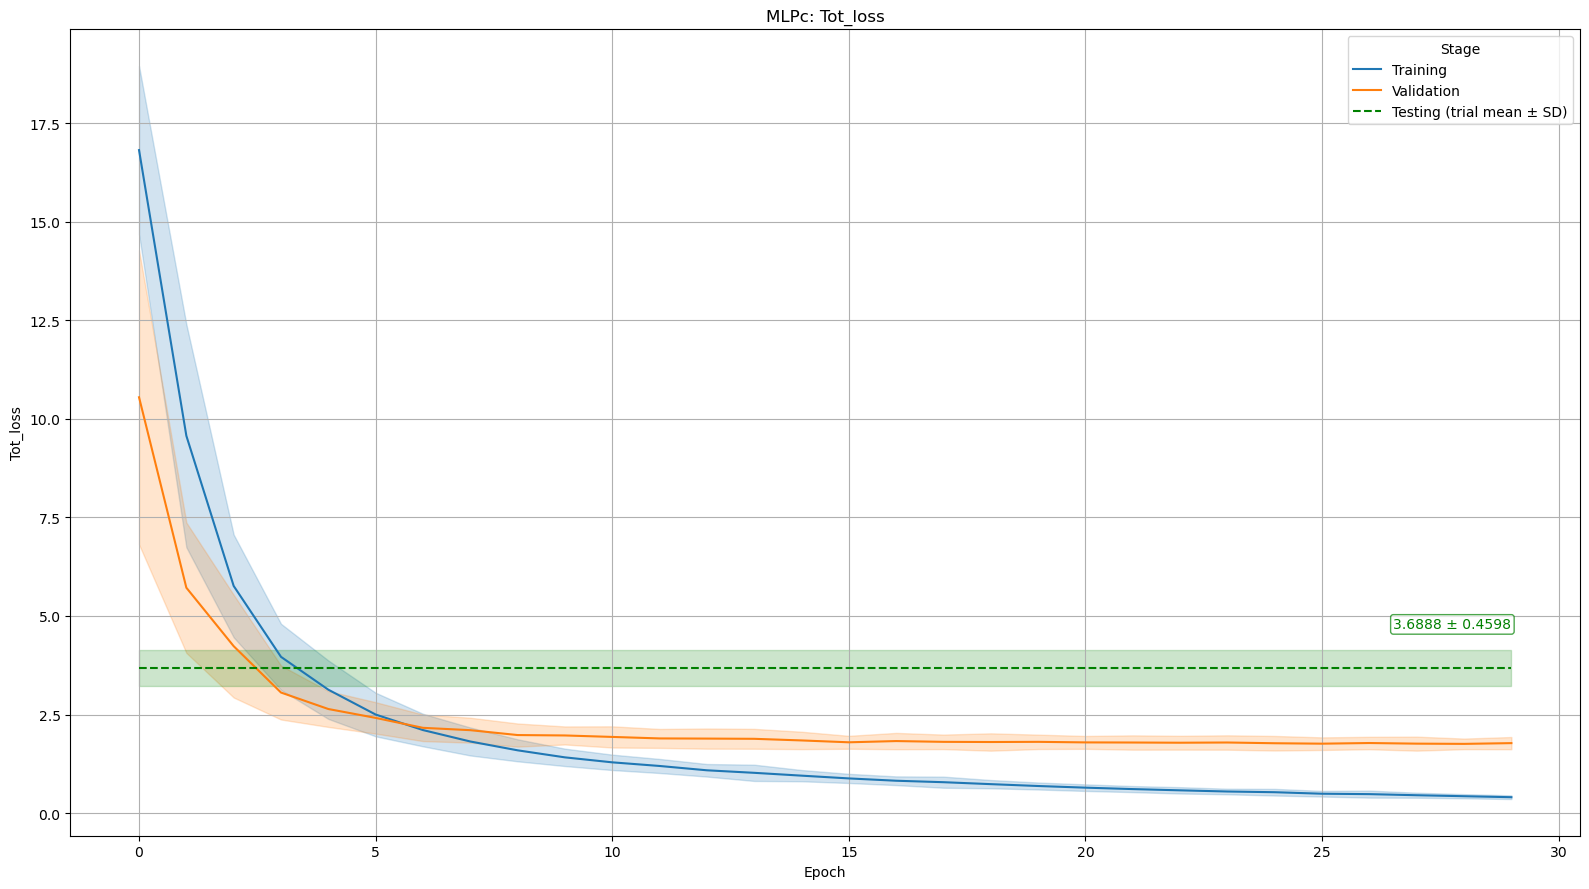

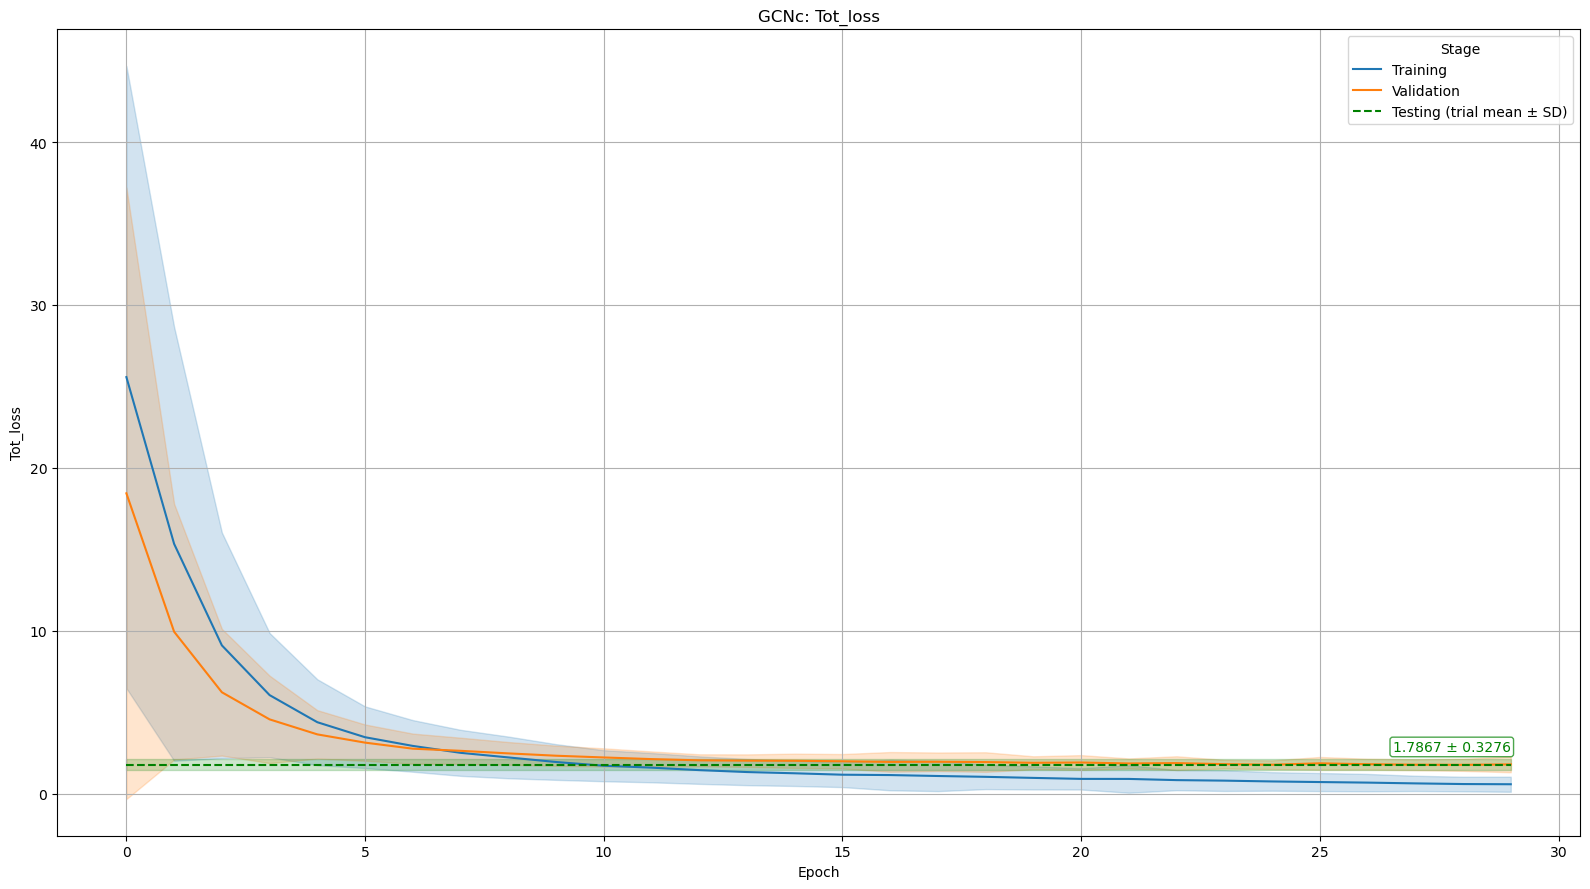

In [20]:
# test results
print('MLPc')
display(MLPc.summary)

print('GCNc')
display(GCNc.summary)

# plots
plot = 'tot_loss'
MLPc.plot(plot)
GCNc.plot(plot)

In [21]:
# for i in ['tot_loss','accuracy','precision','recall','f1']:
#     MLPc.plot(i)
#     GCNc.plot(i)

---
versions of multitrain and experiment modules used here are below. Going to combine these + autoplot

In [ ]:
# class MultiTrainingModule():
#     def __init__(self, model_class, model_kwargs, training_class, training_kwargs, num_trials:int, comment = None):
#         # get dir
#         self.folder = self._get_dir(comment)

#         # init trackers
#         self.trial_metrics = {}
#         self.test_metrics = {}

#         # trial loop
#         for trial in tqdm(range(num_trials)):

#             # define model
#             model = model_class(**model_kwargs)

#             # define, run experiment
#             training_module = training_class(model=model, **training_kwargs)

#             # save trial results
#             self.trial_metrics[trial] = training_module.trial_metrics
#             self.train_results = self._trial_to_csv(self.trial_metrics, 'train')
#             self.val_results = self._trial_to_csv(self.trial_metrics, 'val')

#             # save test results
#             self.test_metrics[trial] = training_module.test_metrics
#             self.test_results = self._test_to_csv(self.test_metrics)

#             # save model
#             state_dict = model.state_dict()
#             torch.save(state_dict, self.folder / f'model_trial_{trial}.pth')

#     def _get_dir(self, comment):
#         # get date, time
#         date = datetime.now().strftime("%Y-%m-%d")
#         time = datetime.now().strftime("%Hh%Mm%Ss").lower()

#         # get dir name
#         dir_name = f'{date}_{time}'

#         if (comment != None) & (type(comment) == str): 
#             dir_name = dir_name + f'_{comment}' # append comment if applicable

#         # create folder
#         folder = Path(f'./output/{dir_name}')
#         folder.mkdir(parents=True, exist_ok=True)

#         return folder

#     def _trial_to_csv(self, metrics_dict, col:str):
#         # trial dict to dataframe
#         results = pd.DataFrame(
#             [
#                 {'trial':trial, 'epoch':epoch, **epoch_metrics[col]} # col: 'train' or 'val'
#                 for trial, trial_metrics in metrics_dict.items() # 
#                 for epoch, epoch_metrics in trial_metrics.items()
#             ]
#         )
        
#         # write to csv
#         results.to_csv(self.folder / f'{col}.csv')

#         return results

#     def _test_to_csv(self, metrics_dict, col:str='test'):
#         # test dict to dataframe
#         results = pd.DataFrame(
#             [
#                 {'trial':trial, **metrics}
#                 for trial, metrics in metrics_dict.items()
#             ]
#         )

#         # write to csv
#         results.to_csv(self.folder / f'{col}.csv')

#         return results

In [ ]:
# class Experiment():
#     def __init__(
#             self, data, generator, model_class:nn.Module, training_class:TrainingModule, # required
#             batch_size:int=64, val_size:int=0.15, test_size:int=0.15, # for data_module
#             model_kwargs:dict={}, training_kwargs:dict={}, num_trials:int=10, comment:str=None # for training_module
#         ):
        
#         # define data module
#         self.data_module = DataModule(
#             X=data.X,
#             y=data.y,
#             generator=generator,
#             batch_size=batch_size,
#             val_size=val_size,
#             test_size=test_size
#         )

#         # run experiment
#         self.training_module = MultiTrainingModule(
#                 model_class=model_class,
#                 model_kwargs=model_kwargs,
#                 training_class=training_class,
#                 training_kwargs={
#                     'data_module': self.data_module,
#                     **training_kwargs
#                 },
#                 num_trials=num_trials,
#                 comment=comment
#         )

#         # get summary, assign instance vars
#         self.summary = self._get_summary()
#         self.comment = comment

#     def _get_summary(self):
#         # copy data
#         test = self.training_module.test_results.copy()

#         # get list of metrics
#         metrics = test.drop(columns='trial').columns.to_list()

#         # summarize (mean, sd) per metric
#         summary = {}
#         for metric in metrics:
#             summary[metric] = {'mean':test[metric].mean(), 'std':test[metric].std()}

#         # convert to df, export as csv
#         summary = pd.DataFrame(summary)
#         summary.to_csv(self.training_module.folder / 'summary.csv')

#         return summary

#     def plot(self, metric:str, title:bool=True, save_fig:bool=True, return_fig:bool=False):
#         # copy data
#         train = self.training_module.train_results.copy()
#         val = self.training_module.val_results.copy()
#         test = self.summary[metric]

#         # add stage, get combined df
#         train['stage'] = 'Training'
#         val['stage'] = 'Validation'
#         dev = pd.concat([train, val])

#         # define plot
#         fig, ax = plt.subplots(figsize=(16, 9))

#         # plot dev set results
#         sns.lineplot(data=dev, x='epoch', y=metric, hue='stage', errorbar='sd')

#         # plot test set line
#         ax.hlines(
#             y=test['mean'], 
#             xmin=min(dev['epoch']),
#             xmax=max(dev['epoch']),
#             colors='green', 
#             linestyles='--', 
#             label='Testing (trial mean ± SD)'
#         )

#         # plot test set area
#         ax.fill_between(
#             x=dev['epoch'].unique(),
#             y1=test['mean'] - test['std'],
#             y2=test['mean'] + test['std'],
#             color='green',
#             alpha=0.2,
#         )

#         # add test results label
#         ax.text(
#             x=max(dev['epoch']), # x pos = final (max) epoch
#             y=test['mean'] + 2*test['std'], # y pos = 2 std above mean
#             s=f'{test['mean']:.4f} ± {test['std']:.4f}', # label
#             va='bottom', # vert align
#             ha='right', # horz align
#             color='green',
#             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='green', alpha=0.7)
#         )

#         # lazy title
#         if title == True:
#             plt.title(f'{self.comment}: {metric.capitalize()}')
        
#         # axis labels
#         ax.set_xlabel("Epoch")
#         ax.set_ylabel(metric.capitalize())
#         ax.legend(title='Stage')
#         ax.grid(True)
#         fig.tight_layout()

#         # save plot
#         if save_fig == True:
#             fig.savefig(self.training_module.folder / f'{self.comment}_{metric}.svg')

#         # return fig
#         if return_fig == True:
#             return fig